# Accessing ROI Pixel Arrays

A typical `craterpy` workflow defines regions of interest (ROIs) around craters and computes zonal statistics over a raster with `get_stats`. Sometimes you want the *raw* pixel values inside each ROI so you can run your own analysis (custom statistics, histograms, masking, etc.). `get_arrays` returns those underlying values as masked arrays.

Here we use the sample data files `moon_craters_km.csv` crater list and `moon.tif` image from `craterpy.sample_data`.

In [1]:
from craterpy import CraterDatabase, sample_data

craters = sample_data["moon_craters_km.csv"]
moon_tif = sample_data["moon.tif"]

cdb = CraterDatabase(craters, "moon", units="km")
cdb

/home/cjtu/projects/craterpy/craterpy/helper.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


CraterDatabase of length 786 with attributes lat, lon, rad, center.

Add a `rim` annulus region (1 to 1.5 crater radii past the rim), then compute zonal statistics over the raster as usual with [`get_stats`](https://craterpy.readthedocs.io/latest/api.html#craterpy.classes.CraterDatabase.get_stats).

In [ ]:
cdb.add_annuli("rim", 1, 1.5)
stats = cdb.get_stats(moon_tif, "rim")
stats.head()

Generating polygons:   0%|          | 0/786 [00:00<?, ?it/s]

Computing Zonal Stats:   0%|          | 0/1 [00:00<?, ?it/s]

,Diameter (km),Latitude,Longitude,mean_rim,count_rim,std_rim
0,1145.53,34.72,-14.91,63.856143,2857,16.150758
1,996.84,-47.77,91.99,83.909259,2700,29.274694
2,875.75,8.35,30.83,60.931741,1465,16.523376
3,840.35,-7.83,53.67,68.728070,1368,15.506291
4,714.50,-20.59,-17.29,64.739488,1094,19.162319


## Accessing the underlying arrays

[`get_arrays`](https://craterpy.readthedocs.io/latest/api.html#craterpy.classes.CraterDatabase.get_arrays) takes the same arguments as [`get_stats`](https://craterpy.readthedocs.io/latest/api.html#craterpy.classes.CraterDatabase.get_stats), but each cell holds the `numpy.ma.MaskedArray` of pixel values clipped to that crater's ROI instead of a single statistic.

In [4]:
arrays = cdb.get_arrays(moon_tif, "rim")
roi = arrays["rim"].iloc[0]
print(type(roi), roi.shape)
roi

Extracting Arrays:   0%|          | 0/1 [00:00<?, ?it/s]

<class 'numpy.ma.MaskedArray'> (119, 146)


masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        ...,
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=np.uint64(999999),
  dtype=uint8)

Now you can do anything you like with the pixels. For example, compute a custom statistic (here the 90th percentile of valid pixels) for every crater, or plot the value distribution of one ROI.

In [5]:
import numpy as np

# Custom per-crater statistic from the raw arrays
p90 = arrays["rim"].apply(lambda a: np.percentile(a.compressed(), 90))
p90.head()

0     84.0
1    120.0
2     82.0
3     88.0
4     91.0
Name: rim, dtype: float64

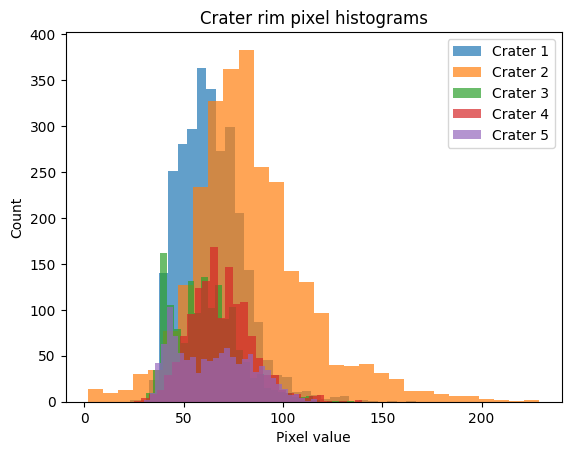

In [7]:
import matplotlib.pyplot as plt

for i in range(5):
    roi = arrays["rim"].iloc[i]
    plt.hist(roi.compressed(), bins=30, histtype="stepfilled", alpha=0.7, label=f"Crater {i+1}")
    plt.xlabel("Pixel value")
    plt.ylabel("Count")
plt.title(f"Crater rim pixel histograms");
plt.legend()
